<a href="https://colab.research.google.com/github/sabdaipry/fiuba-mia-rl1/blob/main/RL1_Desaf%C3%ADo_Snake.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Desafío Práctico: Aprendizaje por Refuerzo I

Autora: **Pryszczuk, Sabrina Daiana**

N°SIU: a2226

Carrera de Especialización en Inteligencia Artificial – Cohorte 22Co2025

---


**Entorno:** Snake (Grilla)
**Agentes:** Q-Learning (Tabular) vs Deep Q-Network (DQN)

El objetivo de este notebook es entrenar y comparar dos enfoques de aprendizaje por refuerzo sobre un entorno personalizado compatible con `gymnasium`.
Para evitar la maldición de la dimensionalidad (la cual haría inviable el uso de Q-Learning clásico), diseñamos un espacio de estados relativo de 11 variables booleanas que representan el entorno inmediato de la serpiente.

In [1]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np
import random
import matplotlib.pyplot as plt
from collections import defaultdict, deque
import imageio
from IPython.display import Image, display
import torch
import torch.nn as nn
import torch.optim as optim
import warnings
warnings.filterwarnings('ignore')

## 1. Definición del Entorno e Ingeniería de Características
Implementamos la lógica del entorno. La función `_get_state()` es la clave de nuestra arquitectura: abstrae la grilla a un vector booleano de 11 posiciones (peligro inmediato, dirección actual y ubicación de la recompensa).

In [2]:
class SnakeEnv(gym.Env):
    def __init__(self, grid_size=10):
        super(SnakeEnv, self).__init__()
        self.grid_size = grid_size

        # Acciones discretas: 0: Arriba, 1: Derecha, 2: Abajo, 3: Izquierda
        self.action_space = spaces.Discrete(4)

        # El espacio de observación (estado) son 11 variables booleanas (0 o 1)
        self.observation_space = spaces.MultiBinary(11)

        self.reset()

    def reset(self, seed=None):
        super().reset(seed=seed)
        # Inicializar la serpiente en el medio
        self.head = [self.grid_size // 2, self.grid_size // 2]
        self.body = [self.head.copy()]
        self.direction = 1 # Arranca mirando a la derecha
        self.score = 0
        self.done = False

        self._place_food()
        return self._get_state(), {}

    def _place_food(self):
        while True:
            self.food = [random.randint(0, self.grid_size - 1), random.randint(0, self.grid_size - 1)]
            if self.food not in self.body:
                break

    def step(self, action):
        # Actualizar dirección (evitando que dé vuelta en U)
        if (action == 0 and self.direction != 2) or \
           (action == 1 and self.direction != 3) or \
           (action == 2 and self.direction != 0) or \
           (action == 3 and self.direction != 1):
            self.direction = action

        # Mover la cabeza
        if self.direction == 0: self.head[0] -= 1 # Arriba
        elif self.direction == 1: self.head[1] += 1 # Derecha
        elif self.direction == 2: self.head[0] += 1 # Abajo
        elif self.direction == 3: self.head[1] -= 1 # Izquierda

        # Comprobar colisiones (paredes o su propio cuerpo)
        if (self.head[0] < 0 or self.head[0] >= self.grid_size or
            self.head[1] < 0 or self.head[1] >= self.grid_size or
            self.head in self.body):
            self.done = True
            reward = -10 # Castigo severo por chocar
            return self._get_state(), reward, self.done, False, {}

        self.body.insert(0, self.head.copy())

        # Comprobar si comió (recompensa)
        if self.head == self.food:
            self.score += 1
            reward = 10 # Recompensa por comer
            self._place_food()
        else:
            self.body.pop() # Eliminar la cola si no comió
            reward = -0.1 # Pequeño castigo por cada paso para evitar bucles infinitos

        return self._get_state(), reward, self.done, False, {}

    def _get_state(self):
        head_x, head_y = self.head

        # Direcciones actuales
        dir_u = self.direction == 0
        dir_r = self.direction == 1
        dir_d = self.direction == 2
        dir_l = self.direction == 3

        # Peligro recto, derecha o izquierda
        danger_s, danger_r, danger_l = 0, 0, 0

        # Función auxiliar para chequear colisiones
        def is_collision(x, y):
            return x < 0 or x >= self.grid_size or y < 0 or y >= self.grid_size or [x, y] in self.body

        if dir_u:
            danger_s = is_collision(head_x - 1, head_y)
            danger_r = is_collision(head_x, head_y + 1)
            danger_l = is_collision(head_x, head_y - 1)
        elif dir_r:
            danger_s = is_collision(head_x, head_y + 1)
            danger_r = is_collision(head_x + 1, head_y)
            danger_l = is_collision(head_x - 1, head_y)
        elif dir_d:
            danger_s = is_collision(head_x + 1, head_y)
            danger_r = is_collision(head_x, head_y - 1)
            danger_l = is_collision(head_x, head_y + 1)
        elif dir_l:
            danger_s = is_collision(head_x, head_y - 1)
            danger_r = is_collision(head_x - 1, head_y)
            danger_l = is_collision(head_x + 1, head_y)

        # Ubicación de la comida
        food_u = self.food[0] < head_x
        food_d = self.food[0] > head_x
        food_l = self.food[1] < head_y
        food_r = self.food[1] > head_y

        # El estado final es una tupla de 11 valores binarios
        state = (int(danger_s), int(danger_r), int(danger_l),
                 int(dir_u), int(dir_r), int(dir_d), int(dir_l),
                 int(food_u), int(food_r), int(food_d), int(food_l))

        return state

## 2. Agente 1: Q-Learning Tabular
Aprovechamos la baja cardinalidad del espacio de observación para utilizar un método tabular. El entrenamiento durará 3000 episodios para garantizar una convergencia suave.

In [3]:
# Hiperparámetros (Q-Learning)
alpha = 0.1    # Tasa de aprendizaje
gamma = 0.9    # Factor de descuento
epsilon = 1.0  # Tasa de exploración inicial
epsilon_min = 0.01
epsilon_decay = 0.998 # Ajustado para 3000 episodios
episodes = 3000

# Inicializar entorno y Q-Table
env = SnakeEnv()
q_table = defaultdict(lambda: np.zeros(env.action_space.n))

# Variables para guardar las métricas del gráfico de convergencia
scores_q = []
rewards_q = []

In [4]:
print("Entrenando Q-Learning Tabular...")
for e in range(episodes):
    state, _ = env.reset()
    total_reward = 0
    done = False

    while not done:
        # Exploración vs Explotación (Epsilon-Greedy)
        if random.uniform(0, 1) < epsilon:
            # Acción aleatoria
            action = env.action_space.sample()
        else:
            # Acción basada en lo aprendido
            action = np.argmax(q_table[state])

        next_state, reward, done, _, _ = env.step(action)

        # Ecuación de actualización de Bellman
        best_next_action = np.argmax(q_table[next_state])
        q_table[state][action] += alpha * (reward + gamma * q_table[next_state][best_next_action] - q_table[state][action])

        state = next_state
        total_reward += reward

    # Decaimiento de epsilon (cada vez explora menos y usa más su experiencia)
    if epsilon > epsilon_min:
        epsilon *= epsilon_decay

    scores_q.append(env.score)
    rewards_q.append(total_reward)

    if (e + 1) % 100 == 0:
        print(f"Episodio {e+1}/{episodes} | Score Promedio (últimos 100): {np.mean(scores_q[-100:]):.2f} | Epsilon: {epsilon:.2f}")
print("Finalizado.")

Entrenando Q-Learning Tabular...
Episodio 100/3000 | Score Promedio (últimos 100): 0.21 | Epsilon: 0.82
Episodio 200/3000 | Score Promedio (últimos 100): 0.72 | Epsilon: 0.67
Episodio 300/3000 | Score Promedio (últimos 100): 1.27 | Epsilon: 0.55
Episodio 400/3000 | Score Promedio (últimos 100): 2.01 | Epsilon: 0.45
Episodio 500/3000 | Score Promedio (últimos 100): 2.57 | Epsilon: 0.37
Episodio 600/3000 | Score Promedio (últimos 100): 3.14 | Epsilon: 0.30
Episodio 700/3000 | Score Promedio (últimos 100): 4.23 | Epsilon: 0.25
Episodio 800/3000 | Score Promedio (últimos 100): 4.87 | Epsilon: 0.20
Episodio 900/3000 | Score Promedio (últimos 100): 6.05 | Epsilon: 0.17
Episodio 1000/3000 | Score Promedio (últimos 100): 6.24 | Epsilon: 0.14
Episodio 1100/3000 | Score Promedio (últimos 100): 6.37 | Epsilon: 0.11
Episodio 1200/3000 | Score Promedio (últimos 100): 9.28 | Epsilon: 0.09
Episodio 1300/3000 | Score Promedio (últimos 100): 9.57 | Epsilon: 0.07
Episodio 1400/3000 | Score Promedio (últ

## 3. Agente 2: Deep Q-Network (DQN)
Reemplazamos la Q-Table por una red neuronal densa implementada con PyTorch. Agregamos el mecanismo de *Experience Replay* para minimizar la correlación entre muestras secuenciales.

In [5]:
# Definición de la red neuronal
class DQN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(DQN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, output_size)
        )

    def forward(self, x):
        return self.net(x)

# Definición del agente que maneja la memoria y el entrenamiento
class DQNAgent:
    def __init__(self):
        self.epsilon = 1.0
        self.epsilon_min = 0.01
        self.epsilon_decay = 0.998
        self.gamma = 0.9
        self.memory = deque(maxlen=100000)
        self.batch_size = 1000

        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.model = DQN(11, 256, 4).to(self.device)
        self.optimizer = optim.Adam(self.model.parameters(), lr=0.001)
        self.criterion = nn.MSELoss()

    def get_action(self, state, evaluate=False):
        if not evaluate and random.uniform(0, 1) < self.epsilon:
            return random.randint(0, 3)
        state_tensor = torch.tensor(state, dtype=torch.float).unsqueeze(0).to(self.device)
        with torch.no_grad():
            return torch.argmax(self.model(state_tensor)).item()

    def remember(self, state, action, reward, next_state, done):
        self.memory.append((state, action, reward, next_state, done))

    def train_step(self):
        if len(self.memory) < self.batch_size:
            return

        mini_sample = random.sample(self.memory, self.batch_size)
        states, actions, rewards, next_states, dones = zip(*mini_sample)

        states = torch.tensor(np.array(states), dtype=torch.float).to(self.device)
        next_states = torch.tensor(np.array(next_states), dtype=torch.float).to(self.device)
        actions = torch.tensor(actions, dtype=torch.long).to(self.device)
        rewards = torch.tensor(rewards, dtype=torch.float).to(self.device)
        dones = torch.tensor(dones, dtype=torch.bool).to(self.device)

        pred = self.model(states)
        target = pred.clone()

        with torch.no_grad():
            next_pred = self.model(next_states)

        # Actualización estilo Bellman
        for idx in range(len(dones)):
            Q_new = rewards[idx]
            if not dones[idx]:
                Q_new = rewards[idx] + self.gamma * torch.max(next_pred[idx])
            target[idx][actions[idx]] = Q_new

        self.optimizer.zero_grad()
        loss = self.criterion(pred, target)
        loss.backward()
        self.optimizer.step()

In [6]:
agent_dqn = DQNAgent()
scores_dqn = []
rewards_dqn = []

print(f"Entrenando DQN en {agent_dqn.device}...")
for e in range(episodes):
    state, _ = env.reset()
    total_reward = 0
    done = False

    while not done:
        action = agent_dqn.get_action(state)
        next_state, reward, done, _, _ = env.step(action)
        agent_dqn.remember(state, action, reward, next_state, done)

        state = next_state
        total_reward += reward

    agent_dqn.train_step()

    if agent_dqn.epsilon > agent_dqn.epsilon_min:
        agent_dqn.epsilon *= agent_dqn.epsilon_decay

    scores_dqn.append(env.score)
    rewards_dqn.append(total_reward)

    if (e + 1) % 100 == 0:
        print(f"Episodio {e+1}/{episodes} | Score Promedio (últimos 100): {np.mean(scores_dqn[-100:]):.2f} | Epsilon: {agent_dqn.epsilon:.2f}")

print("Finalizado.")

Entrenando DQN en cuda...
Episodio 100/3000 | Score Promedio (últimos 100): 0.15 | Epsilon: 0.82
Episodio 200/3000 | Score Promedio (últimos 100): 0.73 | Epsilon: 0.67
Episodio 300/3000 | Score Promedio (últimos 100): 1.32 | Epsilon: 0.55
Episodio 400/3000 | Score Promedio (últimos 100): 1.87 | Epsilon: 0.45
Episodio 500/3000 | Score Promedio (últimos 100): 2.31 | Epsilon: 0.37
Episodio 600/3000 | Score Promedio (últimos 100): 2.96 | Epsilon: 0.30
Episodio 700/3000 | Score Promedio (últimos 100): 3.76 | Epsilon: 0.25
Episodio 800/3000 | Score Promedio (últimos 100): 4.95 | Epsilon: 0.20
Episodio 900/3000 | Score Promedio (últimos 100): 4.80 | Epsilon: 0.17
Episodio 1000/3000 | Score Promedio (últimos 100): 6.61 | Epsilon: 0.14
Episodio 1100/3000 | Score Promedio (últimos 100): 7.30 | Epsilon: 0.11
Episodio 1200/3000 | Score Promedio (últimos 100): 9.10 | Epsilon: 0.09
Episodio 1300/3000 | Score Promedio (últimos 100): 10.31 | Epsilon: 0.07
Episodio 1400/3000 | Score Promedio (últimos 1

## 4. Análisis de Convergencia (Comparativa)
Ploteamos la recompensa promedio de ambos modelos para su comparación.

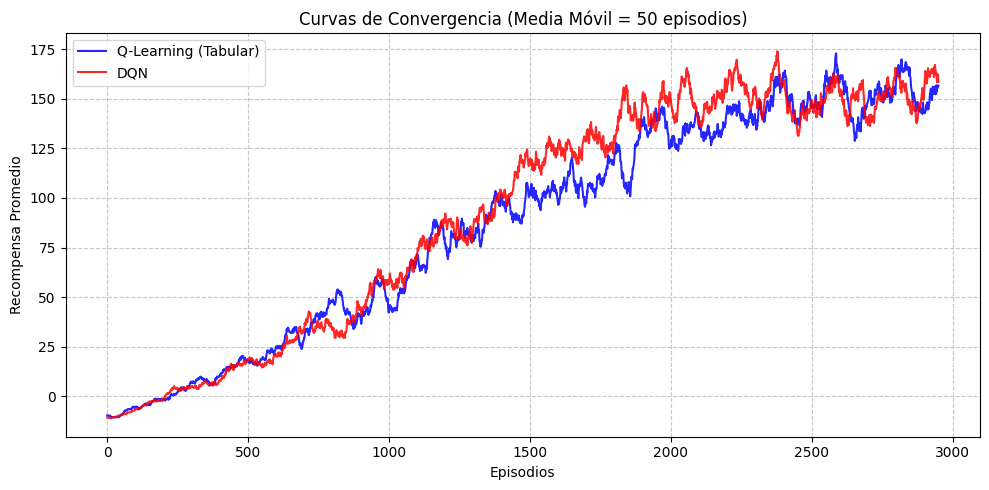

In [7]:
def smooth(data, window_size=50):
    return np.convolve(data, np.ones(window_size)/window_size, mode='valid')

plt.figure(figsize=(10, 5))
plt.plot(smooth(rewards_q), label='Q-Learning (Tabular)', alpha=0.85, color="blue")
plt.plot(smooth(rewards_dqn), label='DQN', alpha=0.85, color="red")
plt.title('Curvas de Convergencia (Media Móvil = 50 episodios)')
plt.xlabel('Episodios')
plt.ylabel('Recompensa Promedio')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

## 5. Simulación de Pruebas de Generalización (Zero-Shot Transfer)
A continuación, evaluamos el conocimiento adquirido en diferentes configuraciones de grilla (10x10, 20x20 y 50x50).
Como el estado es relativo, se espera que el agente se desenvuelva correctamente sin necesidad de reentrenamiento.

In [8]:
def create_frame(env_local):
    grid = np.zeros((env_local.grid_size, env_local.grid_size, 3), dtype=np.uint8)
    grid[env_local.food[0], env_local.food[1]] = [255, 50, 50]
    for segment in env_local.body[1:]:
        grid[segment[0], segment[1]] = [50, 200, 50]
    grid[env_local.head[0], env_local.head[1]] = [0, 150, 0]
    return np.kron(grid, np.ones((20, 20, 1), dtype=np.uint8))

def save_simulation(agent_type, grid_size, max_steps):
    env_test = SnakeEnv(grid_size=grid_size)
    state, _ = env_test.reset()
    frames = []

    while not env_test.done and len(frames) < max_steps:
        frames.append(create_frame(env_test))

        if agent_type == 'q_learning':
            action = np.argmax(q_table[state]) if state in q_table else 0
        else:
            action = agent_dqn.get_action(state, evaluate=True)

        state, _, _, _, _ = env_test.step(action)

    filename = f"snake_{agent_type}_{grid_size}x{grid_size}.gif"
    imageio.mimsave(filename, frames, fps=15)
    print(f"-> Generado: {filename} (Score alcanzado: {env_test.score})")
    display(Image(open(filename, 'rb').read())) # para visualizar en colab directo

Evaluando política Q-Learning en distintas grillas:
-> Generado: snake_q_learning_10x10.gif (Score alcanzado: 18)


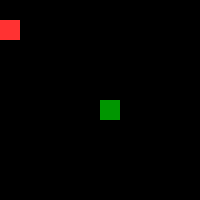

-> Generado: snake_q_learning_20x20.gif (Score alcanzado: 22)


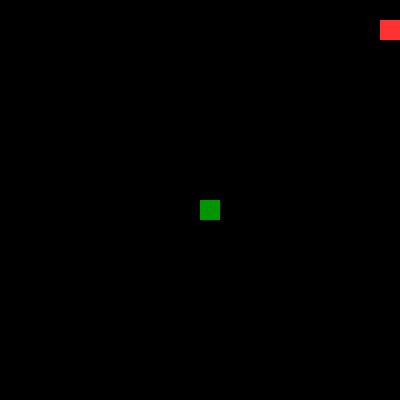

-> Generado: snake_q_learning_50x50.gif (Score alcanzado: 57)


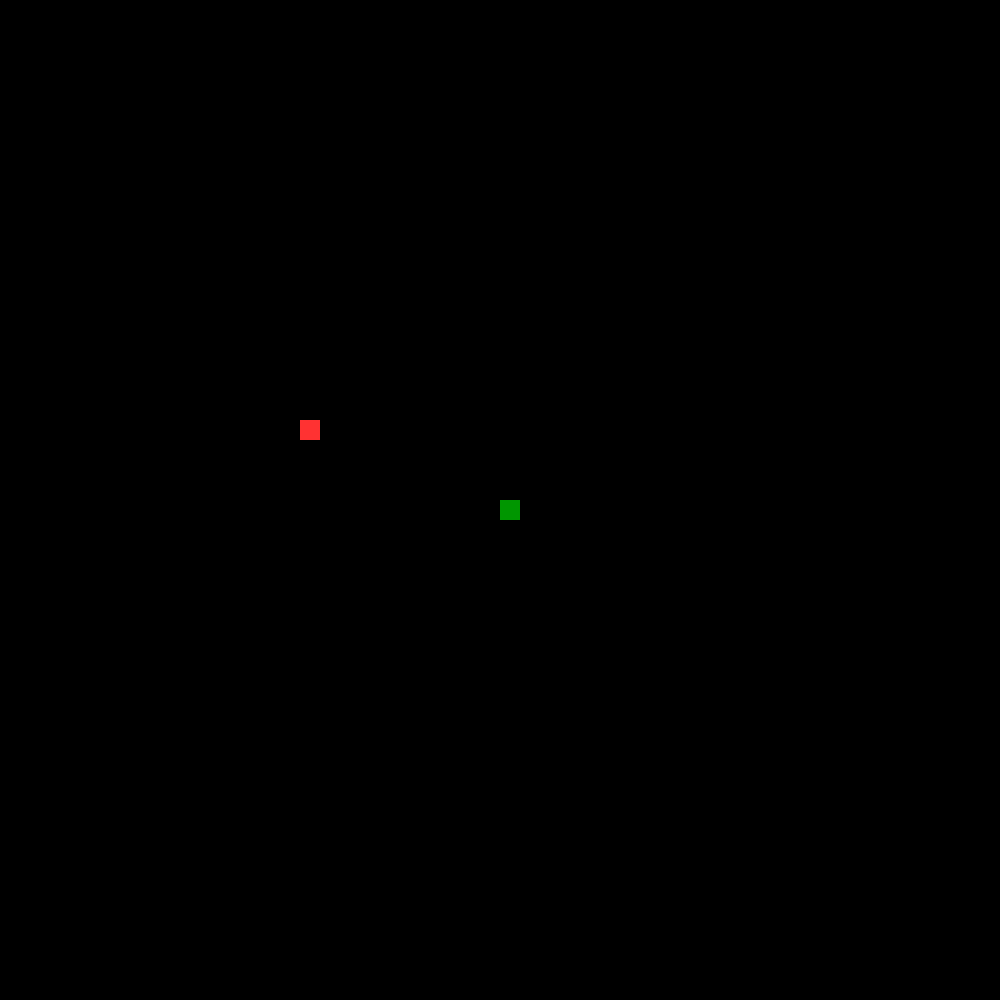

In [11]:
print("Evaluando política Q-Learning en distintas grillas:")
save_simulation('q_learning', 10, 500)
save_simulation('q_learning', 20, 1000)
save_simulation('q_learning', 50, 2000)


Evaluando política DQN en distintas grillas:
-> Generado: snake_dqn_10x10.gif (Score alcanzado: 25)


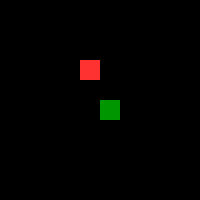

-> Generado: snake_dqn_20x20.gif (Score alcanzado: 34)


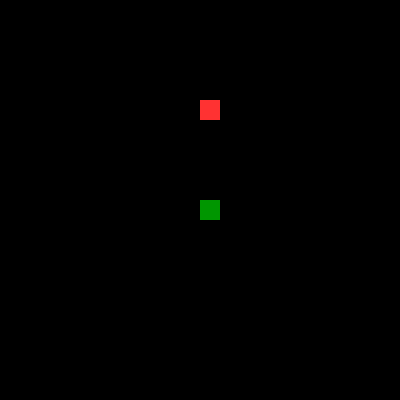

-> Generado: snake_dqn_50x50.gif (Score alcanzado: 31)


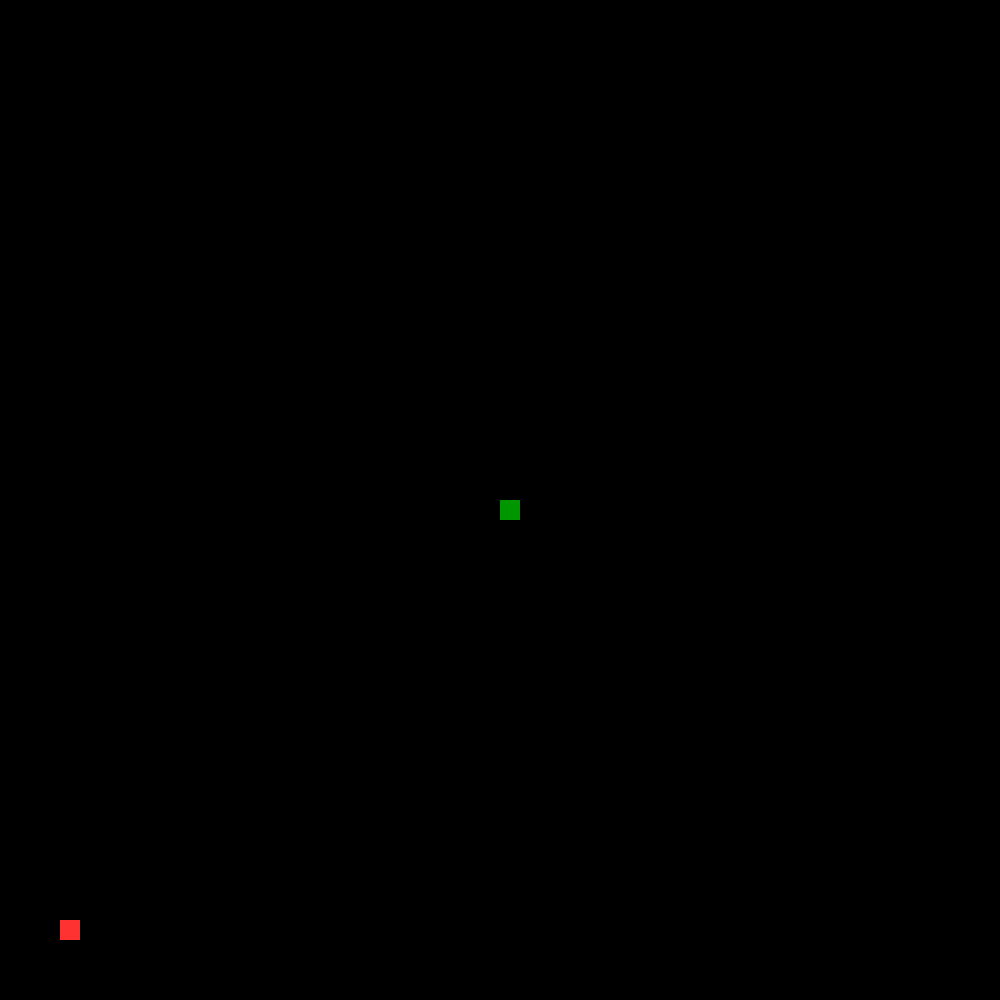

In [12]:
print("\nEvaluando política DQN en distintas grillas:")
save_simulation('dqn', 10, 500)
save_simulation('dqn', 20, 1000)
save_simulation('dqn', 50, 2000)